# AUC de fidelidad ts-MULE para todo `X_test`

Este cuaderno calcula, para cada muestra de `xtest_new.pickle`, las metricas AUC de `deletion` e `insertion` usando dos ?rdenes de segmentos:

1. `absolute`: segmentos ordenados por `|relevancia|` media.
2. `positive_first`: primero los segmentos con relevancia positiva para la clase predicha; luego el resto.

Interpretaci?n esperada: `Deletion AUC` menor e `Insertion AUC` mayor indican que los segmentos seleccionados afectan mas rapido la prediccion del modelo.


In [ ]:
from pathlib import Path
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

PROJECT_ROOT = Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT / 'METHODS' / 'ts-mule'))
warnings.filterwarnings('ignore', category=RuntimeWarning)

from keras.models import load_model
from tsmule.xai.lime import LimeTS
from tsmule.sampling import replace as replacement

print('Proyecto:', PROJECT_ROOT)

## 1. Configuración

Por defecto usa todas las muestras. Si quieres probar rapido antes, cambia `SAMPLE_INDICES = range(10)`.

In [ ]:
with open(PROJECT_ROOT / 'DATA' / 'xtest_new.pickle', 'rb') as file:
    X_test = np.asarray(pickle.load(file), dtype=float)

model = load_model(PROJECT_ROOT / 'MODELS' / 'transfer_learned_tsunami_classifier.keras')

N_RUNS = 5          # Subir a 20 para el an?lisis final, si el tiempo lo permite.
N_SAMPLES = 100
PARTITIONS = 5
WIN_LENGTH = 4
ALPHA = 1e-4
SEGMENTATION_METHOD = 'slopes-sorted'
REPLACE_METHOD = 'zeros'
CLASS_THRESHOLD = 0.5
RANDOM_SEED = 42
SAVE_EVERY = 10
SAMPLE_INDICES = range(len(X_test))

OUTPUT_CSV = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_deletion_insertion_xtest.csv'
OUTPUT_CSV.parent.mkdir(exist_ok=True)

np.random.seed(RANDOM_SEED)
print('X_test:', X_test.shape)
print('Salida:', OUTPUT_CSV)

X_test: (1017, 241, 6)
Salida: /home/ignacio/Proyectos/Proyecto-XAI-2026-main/RESULTS/tsmule_auc_deletion_insertion_xtest.csv


In [17]:
def predict_proba(x_input):
    x_input = np.asarray(x_input)
    if x_input.ndim == 2:
        x_input = x_input[np.newaxis, ...]
    prediction = model([x_input], training=False)
    return np.asarray(prediction).reshape(-1)


def segment_ranking(relevance, segment_mask, ranking='absolute', target_sign=1):
    labels = np.unique(segment_mask)

    if ranking == 'absolute':
        importance = np.array([
            np.mean(np.abs(relevance[segment_mask == label]))
            for label in labels
        ])
        order = np.argsort(importance)[::-1]
        return labels[order], importance[order]

    if ranking == 'positive_first':
        signed = np.array([
            target_sign * np.mean(relevance[segment_mask == label])
            for label in labels
        ])
        positives = np.where(signed > 0)[0]
        others = np.where(signed <= 0)[0]
        order = np.r_[
            positives[np.argsort(signed[positives])[::-1]],
            others[np.argsort(np.abs(signed[others]))[::-1]],
        ]
        return labels[order], signed[order]

    raise ValueError(f'ranking desconocido: {ranking}')


def deletion_insertion_auc(x, relevance, segment_mask, predict_fn, replace_method='zeros', ranking='absolute', target_sign=1):
    ordered_labels, importance = segment_ranking(
        relevance, segment_mask, ranking=ranking, target_sign=target_sign
    )
    baseline = getattr(replacement, replace_method)(x, segment_mask)

    deleted = x.copy()
    inserted = baseline.copy()
    deletion_batch = [deleted.copy()]
    insertion_batch = [inserted.copy()]

    for label in ordered_labels:
        mask = segment_mask == label
        deleted[mask] = baseline[mask]
        inserted[mask] = x[mask]
        deletion_batch.append(deleted.copy())
        insertion_batch.append(inserted.copy())

    fractions = np.arange(len(ordered_labels) + 1) / len(ordered_labels)
    deletion = predict_fn(np.asarray(deletion_batch))
    insertion = predict_fn(np.asarray(insertion_batch))

    assert np.allclose(deletion_batch[0], x)
    assert np.allclose(deletion_batch[-1], baseline)
    assert np.allclose(insertion_batch[0], baseline)
    assert np.allclose(insertion_batch[-1], x)

    return {
        'deletion_auc': float(np.trapezoid(deletion, fractions)),
        'insertion_auc': float(np.trapezoid(insertion, fractions)),
        'gap_auc': float(np.trapezoid(insertion, fractions) - np.trapezoid(deletion, fractions)),
        'n_segments': int(len(ordered_labels)),
        'n_positive_segments': int(np.sum(importance > 0)) if ranking == 'positive_first' else np.nan,
    }

## 2. Calculo por muestra

La celda se puede detener y volver a ejecutar: si el CSV ya existe, omite las muestras procesadas.

In [ ]:
def explain_sample(sample_idx):
    x = X_test[sample_idx]
    original_prediction = float(predict_proba(x)[0])
    predicted_class = int(original_prediction >= CLASS_THRESHOLD)
    target_sign = 1 if predicted_class == 1 else -1

    relevances, local_r2 = [], []
    explainer = None

    for _ in range(N_RUNS):
        explainer = LimeTS(
            n_samples=N_SAMPLES,
            partitions=PARTITIONS,
            win_length=WIN_LENGTH,
            kernel=Lasso(alpha=ALPHA),
            replace_method=REPLACE_METHOD,
        )
        relevance = explainer.explain(
            x,
            predict_proba,
            segmentation_method=SEGMENTATION_METHOD,
        )
        relevances.append(relevance)
        local_r2.append(explainer.score)

    relevance_mean = np.mean(relevances, axis=0)
    segment_mask = explainer._segmenter.segment(x, segmentation_method=SEGMENTATION_METHOD)
    baseline_prediction = float(predict_proba(getattr(replacement, REPLACE_METHOD)(x, segment_mask))[0])

    absolute = deletion_insertion_auc(
        x, relevance_mean, segment_mask, predict_proba, REPLACE_METHOD,
        ranking='absolute', target_sign=target_sign,
    )
    positive_first = deletion_insertion_auc(
        x, relevance_mean, segment_mask, predict_proba, REPLACE_METHOD,
        ranking='positive_first', target_sign=target_sign,
    )

    return {
        'sample_idx': int(sample_idx),
        'original_prediction': original_prediction,
        'baseline_prediction': baseline_prediction,
        'predicted_class': predicted_class,
        'r2_mean': float(np.mean(local_r2)),
        'r2_std': float(np.std(local_r2, ddof=1)) if len(local_r2) > 1 else 0.0,
        'deletion_auc_abs': absolute['deletion_auc'],
        'insertion_auc_abs': absolute['insertion_auc'],
        'gap_auc_abs': absolute['gap_auc'],
        'deletion_auc_positive_first': positive_first['deletion_auc'],
        'insertion_auc_positive_first': positive_first['insertion_auc'],
        'gap_auc_positive_first': positive_first['gap_auc'],
        'n_segments': absolute['n_segments'],
        'n_positive_segments': positive_first['n_positive_segments'],
        'error': '',
    }


processed = set()
RESULTADOS_DELETION_INSERTION = []
if OUTPUT_CSV.exists():
    old = pd.read_csv(OUTPUT_CSV)
    RESULTADOS_DELETION_INSERTION = old.to_dict('records')
    processed = set(old.loc[old['error'].fillna('') == '', 'sample_idx'].astype(int))
    print(f'Reanudando: {len(processed)} muestras ya procesadas.')

pending = [int(i) for i in SAMPLE_INDICES if int(i) not in processed]
print(f'Pendientes: {len(pending)}')

for n, sample_idx in enumerate(pending, start=1):
    try:
        row = explain_sample(sample_idx)
    except Exception as exc:
        row = {'sample_idx': int(sample_idx), 'error': repr(exc)}

    RESULTADOS_DELETION_INSERTION.append(row)

    if n % SAVE_EVERY == 0 or n == len(pending):
        pd.DataFrame(RESULTADOS_DELETION_INSERTION).sort_values('sample_idx').to_csv(OUTPUT_CSV, index=False)
        print(f'Guardado {n}/{len(pending)} pendientes -> {OUTPUT_CSV.name}')

auc_df = pd.DataFrame(RESULTADOS_DELETION_INSERTION).sort_values('sample_idx')
auc_df.head()

Reanudando: 300 muestras ya procesadas.
Pendientes: 717


2026-06-24 03:16:25.557767: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92300


Guardado 10/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 20/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 30/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 40/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 50/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 60/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 70/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 80/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 90/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 100/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 110/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 120/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 130/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 140/717 pendientes -> tsmule_auc_deletion_insertion_xtest.csv
Guardado 150/71

,sample_idx,original_prediction,baseline_prediction,predicted_class,r2_mean,r2_std,deletion_auc_abs,insertion_auc_abs,gap_auc_abs,deletion_auc_positive_first,insertion_auc_positive_first,gap_auc_positive_first,n_segments,n_positive_segments,error
0,0,0.008333,0.008418,0,-0.018523,0.013591,0.008362,0.008456,0.000094,0.008362,0.008456,0.000094,36,0,NaN
1,1,1.000000,0.008418,1,-1.965259,2.271297,0.777866,0.985829,0.207963,0.525223,0.957372,0.432148,35,19,NaN
2,2,0.008096,0.008418,0,0.067679,0.104291,0.008188,0.008421,0.000233,0.008190,0.008419,0.000229,36,1,NaN
3,3,0.995358,0.008418,1,-1.115944,0.893134,0.793184,0.893537,0.100353,0.405338,0.965007,0.559668,36,18,NaN
4,4,0.017962,0.008418,0,-1.137086,1.489536,0.016656,0.026443,0.009787,0.532491,0.020094,-0.512397,36,19,NaN


## 3. Resumen global de AUC

In [19]:
ok = auc_df[auc_df['error'].fillna('') == ''].copy()

summary_cols = [
    'r2_mean',
    'deletion_auc_abs', 'insertion_auc_abs', 'gap_auc_abs',
    'deletion_auc_positive_first', 'insertion_auc_positive_first', 'gap_auc_positive_first',
]

ok[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
r2_mean,1017.0,-7174.191150,228645.150016,-7.291598e+06,-1.025588,-0.628436,-0.125777,0.728160
deletion_auc_abs,1017.0,0.310097,0.326002,1.612706e-03,0.009177,0.189219,0.611591,0.986222
insertion_auc_abs,1017.0,0.410913,0.392657,5.236094e-03,0.009613,0.376800,0.832166,0.986228
gap_auc_abs,1017.0,0.100816,0.224126,-5.890069e-01,-0.000543,0.003618,0.193158,0.905620
deletion_auc_positive_first,1017.0,0.262030,0.253331,7.895711e-03,0.016544,0.202683,0.435958,0.984526
insertion_auc_positive_first,1017.0,0.418707,0.433120,2.400261e-03,0.008444,0.157770,0.930751,0.986228
gap_auc_positive_first,1017.0,0.156677,0.447405,-8.946802e-01,-0.125981,-0.000569,0.585108,0.968519


In [20]:
ok.groupby('predicted_class')[summary_cols].agg(['mean', 'std', 'median', 'count'])

r2_mean                                deletion_auc_abs  \
                         mean            std    median count             mean   
predicted_class                                                                 
0                   -2.787579      15.551671 -0.471881   600         0.114998   
1               -17492.757438  357070.766982 -0.706161   417         0.590815   

                                          insertion_auc_abs            ...  \
                      std    median count              mean       std  ...   
predicted_class                                                        ...   
0                0.206762  0.010027   600          0.137170  0.238002  ...   
1                0.253206  0.626867   417          0.804789  0.177201  ...   

                deletion_auc_positive_first        \
                                     median count   
predicted_class                                     
0                                  0.066852   600   
1                                  0.264006   417   

                insertion_auc_positive_first                            \
                                        mean       std    median count   
predicted_class                                                          
0                                   0.075163  0.147995  0.008982   600   
1                                   0.913014  0.107095  0.957283   417   

                gap_auc_positive_first                            
                                  mean       std    median count  
predicted_class                                                   
0                            -0.172773  0.210501 -0.047185   600  
1                             0.630706  0.208061  0.645486   417  

[2 rows x 28 columns]

## 4. Graficos

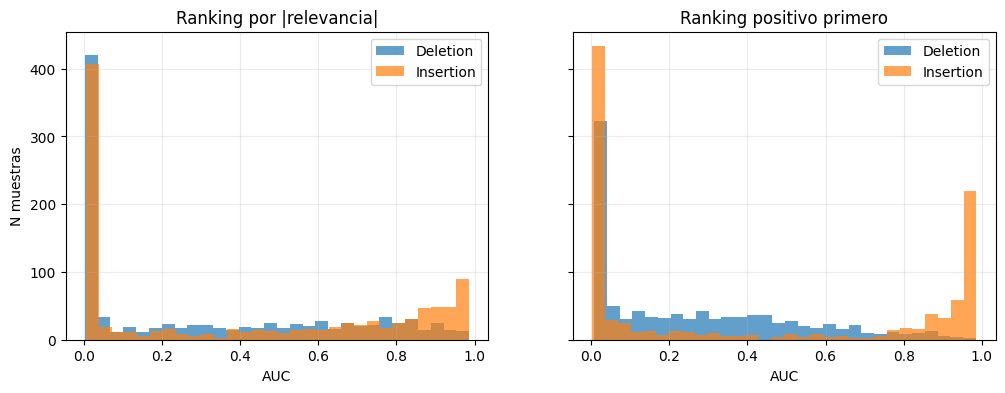

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(ok['deletion_auc_abs'], bins=30, alpha=.7, label='Deletion')
axes[0].hist(ok['insertion_auc_abs'], bins=30, alpha=.7, label='Insertion')
axes[0].set_title('Ranking por |relevancia|')
axes[0].set_xlabel('AUC')
axes[0].set_ylabel('N muestras')
axes[0].legend()

axes[1].hist(ok['deletion_auc_positive_first'], bins=30, alpha=.7, label='Deletion')
axes[1].hist(ok['insertion_auc_positive_first'], bins=30, alpha=.7, label='Insertion')
axes[1].set_title('Ranking positivo primero')
axes[1].set_xlabel('AUC')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=.25)
plt.show()

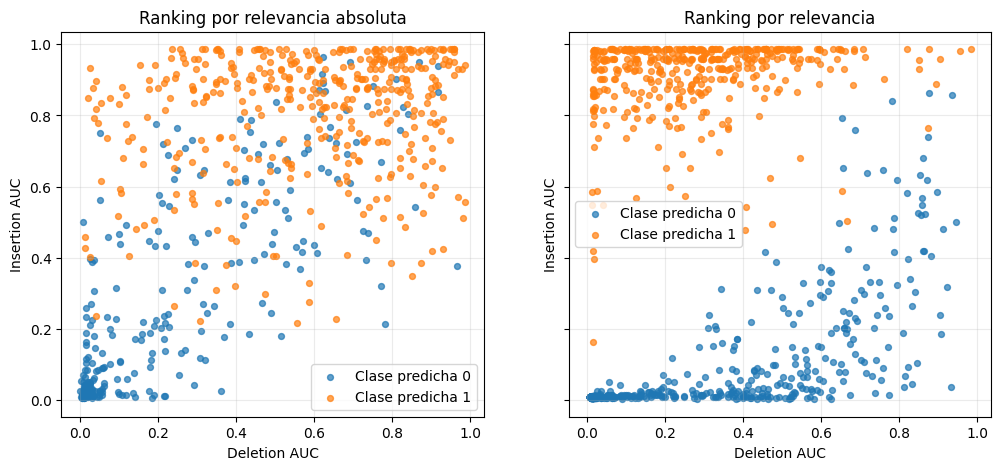

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for class_id, group in ok.groupby('predicted_class'):
    label = f'Clase predicha {class_id}'
    axes[0].scatter(group['deletion_auc_abs'], group['insertion_auc_abs'], s=18, alpha=.7, label=label)
    axes[1].scatter(group['deletion_auc_positive_first'], group['insertion_auc_positive_first'], s=18, alpha=.7, label=label)

axes[0].set_title('Ranking por relevancia absoluta')
axes[1].set_title('Ranking por relevancia')
for ax in axes:
    ax.set_xlabel('Deletion AUC')
    ax.set_ylabel('Insertion AUC')
    ax.grid(alpha=.25)
    ax.legend()
plt.show()

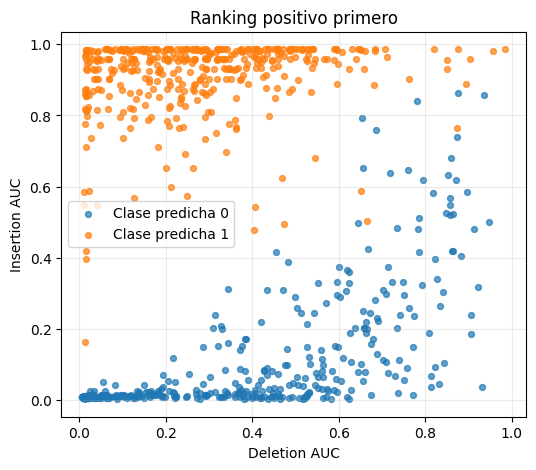

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
for class_id, group in ok.groupby('predicted_class'):
    label = f'Clase predicha {class_id}'
    ax.scatter(group['deletion_auc_positive_first'], group['insertion_auc_positive_first'], s=18, alpha=.7, label=label)

ax.set(
    xlabel='Deletion AUC',
    ylabel='Insertion AUC',
    title='Ranking positivo primero',
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for class_id, group in ok.groupby('predicted_class'):
    ax.scatter(group['deletion_auc_positive'], group['insertion_auc_positive'], s=18, alpha=.7, label=f'Clase predicha {class_id}')
ax.set(
    xlabel='Deletion AUC positivo',
    ylabel='Insertion AUC positivo',
    title='AUC por muestra: solo segmentos positivos',
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

## 5. Casos extremos para revisar

- `gap_auc` alto: insertion se recupera mucho mas que deletion, señal favorable.
- `gap_auc` bajo o negativo: revisar explicaci?n; puede indicar ranking debil, saturacion del clasificador o segmentos con efectos mixtos.

In [ ]:
cols = [
    'sample_idx', 'predicted_class', 'original_prediction', 'r2_mean',
    'deletion_auc_abs', 'insertion_auc_abs', 'gap_auc_abs',
    'deletion_auc_positive_first', 'insertion_auc_positive_first', 'gap_auc_positive_first',
    'n_segments', 'n_positive_segments',
]

print('Mejores por gap positivo primero')
display(ok.sort_values('gap_auc_positive_first', ascending=False)[cols].head(10))

print('Peores por gap positivo primero')
display(ok.sort_values('gap_auc_positive_first', ascending=True)[cols].head(10))

Mejores por gap positivo primero


,sample_idx,predicted_class,original_prediction,r2_mean,deletion_auc_abs,insertion_auc_abs,gap_auc_abs,deletion_auc_positive_first,insertion_auc_positive_first,gap_auc_positive_first,n_segments,n_positive_segments
69,69,1,0.999455,-0.848886,0.472857,0.919367,0.446510,0.032591,0.982422,0.949831,35,17
252,252,1,1.000000,-0.676703,0.103323,0.593589,0.490266,0.015029,0.957449,0.942420,36,15
228,228,1,0.999996,-0.289670,0.160935,0.664021,0.503087,0.042941,0.982453,0.939512,36,20
307,307,1,0.999878,-0.385816,0.332112,0.862025,0.529912,0.020053,0.957702,0.937649,36,22
232,232,1,0.999434,-1.002572,0.041533,0.897840,0.856307,0.041313,0.977446,0.936134,36,22
9,9,1,1.000000,-0.753687,0.387778,0.932460,0.544682,0.059088,0.986166,0.927078,36,19
201,201,1,1.000000,-0.661202,0.076283,0.849365,0.773081,0.061640,0.986215,0.924574,36,17
257,257,1,1.000000,-0.883629,0.340125,0.866167,0.526042,0.063621,0.986227,0.922606,36,16
64,64,1,1.000000,-0.181259,0.692649,0.986225,0.293575,0.064095,0.986228,0.922133,36,18
178,178,1,0.999999,-0.426979,0.427897,0.771505,0.343608,0.016549,0.930751,0.914202,36,19


Peores por gap positivo primero


,sample_idx,predicted_class,original_prediction,r2_mean,deletion_auc_abs,insertion_auc_abs,gap_auc_abs,deletion_auc_positive_first,insertion_auc_positive_first,gap_auc_positive_first,n_segments,n_positive_segments
196,196,0,0.016461,-0.426631,0.183940,0.133600,-0.050340,0.831899,0.043798,-0.788101,36,18
269,269,0,0.009609,-0.427329,0.527635,0.382355,-0.145280,0.814181,0.068468,-0.745713,36,18
251,251,0,0.008416,-0.607171,0.179968,0.189668,0.009699,0.844283,0.104504,-0.739779,36,22
88,88,0,0.020396,-0.752955,0.691444,0.609651,-0.081793,0.758005,0.090702,-0.667302,36,14
51,51,0,0.232930,-0.586272,0.782260,0.213122,-0.569138,0.904797,0.240119,-0.664678,36,18
84,84,0,0.112066,-0.709263,0.635180,0.640431,0.005251,0.771090,0.150548,-0.620542,36,17
147,147,0,0.362563,-0.447049,0.421375,0.552530,0.131155,0.708118,0.106292,-0.601827,36,20
101,101,0,0.010831,-0.662303,0.564885,0.368225,-0.196660,0.701733,0.112991,-0.588743,36,19
141,141,0,0.010873,-0.640899,0.103696,0.110476,0.006780,0.595526,0.022992,-0.572534,36,19
5,5,0,0.023191,-0.899726,0.488541,0.244345,-0.244196,0.645214,0.079578,-0.565635,36,15
